# AI Product Usage Analytics

*An end-to-end analysis of user behavior, feature engagement, and churn patterns for an AI SaaS product.*

**Author:** Bengisu Arican
**Date:** 2026

## 1. Data Generation

Synthetic data is generated using `np.random.seed(42)` for reproducibility. Three tables are created: `users` (500 rows), `feature_usage` (~17,000 rows), and `churn_log` (233 rows).

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import random
from datetime import datetime, timedelta

In [2]:
np.arange(10001, 10501)

array([10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009,
       10010, 10011, 10012, 10013, 10014, 10015, 10016, 10017, 10018,
       10019, 10020, 10021, 10022, 10023, 10024, 10025, 10026, 10027,
       10028, 10029, 10030, 10031, 10032, 10033, 10034, 10035, 10036,
       10037, 10038, 10039, 10040, 10041, 10042, 10043, 10044, 10045,
       10046, 10047, 10048, 10049, 10050, 10051, 10052, 10053, 10054,
       10055, 10056, 10057, 10058, 10059, 10060, 10061, 10062, 10063,
       10064, 10065, 10066, 10067, 10068, 10069, 10070, 10071, 10072,
       10073, 10074, 10075, 10076, 10077, 10078, 10079, 10080, 10081,
       10082, 10083, 10084, 10085, 10086, 10087, 10088, 10089, 10090,
       10091, 10092, 10093, 10094, 10095, 10096, 10097, 10098, 10099,
       10100, 10101, 10102, 10103, 10104, 10105, 10106, 10107, 10108,
       10109, 10110, 10111, 10112, 10113, 10114, 10115, 10116, 10117,
       10118, 10119, 10120, 10121, 10122, 10123, 10124, 10125, 10126,
       10127, 10128,

In [3]:
np.random.choice(["free", "pro"], size=500)

array(['free', 'free', 'pro', 'free', 'free', 'pro', 'free', 'free',
       'pro', 'pro', 'free', 'free', 'free', 'pro', 'pro', 'pro', 'free',
       'free', 'pro', 'pro', 'pro', 'pro', 'free', 'free', 'free', 'pro',
       'free', 'free', 'free', 'pro', 'pro', 'pro', 'free', 'free',
       'free', 'free', 'free', 'free', 'pro', 'pro', 'pro', 'free', 'pro',
       'pro', 'free', 'pro', 'pro', 'pro', 'pro', 'pro', 'free', 'pro',
       'free', 'free', 'pro', 'free', 'pro', 'pro', 'free', 'free',
       'free', 'pro', 'free', 'free', 'pro', 'pro', 'free', 'pro', 'free',
       'pro', 'pro', 'pro', 'pro', 'pro', 'free', 'pro', 'free', 'pro',
       'free', 'free', 'free', 'free', 'pro', 'pro', 'free', 'free',
       'pro', 'pro', 'free', 'free', 'pro', 'free', 'free', 'free', 'pro',
       'pro', 'pro', 'pro', 'pro', 'pro', 'pro', 'pro', 'free', 'pro',
       'free', 'free', 'free', 'free', 'pro', 'free', 'pro', 'pro', 'pro',
       'pro', 'free', 'pro', 'free', 'pro', 'free', 'free', 'pr

In [4]:
df=pd.DataFrame({
    "user_id": np.arange(10001, 10501),
    "plan_type": np.random.choice(["free", "pro"], size=500),
    "country" : np.random.choice(["USA", "Germany", "Turkey", "Japan", "Brazil", "India", "UK", "South Korea"], size=500)
})

In [5]:
df.head()

,user_id,plan_type,country
0,10001,pro,USA
1,10002,free,Brazil
2,10003,pro,Brazil
3,10004,free,Japan
4,10005,free,Brazil


In [6]:
datetime(2026, 3, 1) - datetime(2025, 1, 1)

datetime.timedelta(days=424)

In [7]:
start_date = datetime(2025, 1, 1)
days = np.random.randint(0, 424, size=500)
signup_dates = [start_date + timedelta(days=int(d)) for d in days]

In [8]:
signup_dates[:5]

[datetime.datetime(2025, 7, 27, 0, 0),
 datetime.datetime(2025, 5, 15, 0, 0),
 datetime.datetime(2025, 8, 26, 0, 0),
 datetime.datetime(2025, 5, 10, 0, 0),
 datetime.datetime(2025, 3, 22, 0, 0)]

In [9]:
np.random.seed(42)

start_date = datetime(2025, 1, 1)
days = np.random.randint(0, 424, size=500)
signup_dates = [start_date + timedelta(days=int(d)) for d in days]

df=pd.DataFrame({
    "user_id": np.arange(10001, 10501),
    "plan_type": np.random.choice(["free", "pro"], size=500),
    "country" : np.random.choice(["USA", "Germany", "Turkey", "Japan", "Brazil", "India", "UK", "South Korea"], size=500),
    "signup_dates" : signup_dates , 
    "status" : np.random.choice(["active","churned"], size=500)
})

In [10]:
df.head()

,user_id,plan_type,country,signup_dates,status
0,10001,pro,UK,2025-04-13,churned
1,10002,free,UK,2025-12-15,active
2,10003,free,UK,2025-09-28,active
3,10004,pro,Brazil,2025-04-17,active
4,10005,free,Brazil,2025-03-13,churned


In [11]:
for index, row in df.iterrows():
    print(row["user_id"])

10001
10002
10003
10004
10005
10006
10007
10008
10009
10010
10011
10012
10013
10014
10015
10016
10017
10018
10019
10020
10021
10022
10023
10024
10025
10026
10027
10028
10029
10030
10031
10032
10033
10034
10035
10036
10037
10038
10039
10040
10041
10042
10043
10044
10045
10046
10047
10048
10049
10050
10051
10052
10053
10054
10055
10056
10057
10058
10059
10060
10061
10062
10063
10064
10065
10066
10067
10068
10069
10070
10071
10072
10073
10074
10075
10076
10077
10078
10079
10080
10081
10082
10083
10084
10085
10086
10087
10088
10089
10090
10091
10092
10093
10094
10095
10096
10097
10098
10099
10100
10101
10102
10103
10104
10105
10106
10107
10108
10109
10110
10111
10112
10113
10114
10115
10116
10117
10118
10119
10120
10121
10122
10123
10124
10125
10126
10127
10128
10129
10130
10131
10132
10133
10134
10135
10136
10137
10138
10139
10140
10141
10142
10143
10144
10145
10146
10147
10148
10149
10150
10151
10152
10153
10154
10155
10156
10157
10158
10159
10160
10161
10162
10163
10164
10165
10166
1016

In [12]:
for index, row in df.iterrows():
    n = np.random.randint(20, 50)
    print(row["user_id"], n)

10001 48
10002 49
10003 40
10004 31
10005 44
10006 35
10007 43
10008 31
10009 34
10010 44
10011 29
10012 49
10013 44
10014 26
10015 39
10016 24
10017 20
10018 49
10019 36
10020 22
10021 32
10022 33
10023 43
10024 49
10025 37
10026 23
10027 37
10028 49
10029 24
10030 44
10031 35
10032 20
10033 40
10034 33
10035 34
10036 28
10037 34
10038 36
10039 44
10040 43
10041 23
10042 31
10043 46
10044 45
10045 24
10046 48
10047 24
10048 30
10049 47
10050 25
10051 26
10052 43
10053 33
10054 43
10055 30
10056 49
10057 32
10058 21
10059 44
10060 26
10061 39
10062 23
10063 46
10064 27
10065 39
10066 48
10067 41
10068 40
10069 38
10070 32
10071 33
10072 29
10073 30
10074 21
10075 44
10076 45
10077 28
10078 36
10079 45
10080 22
10081 43
10082 25
10083 24
10084 24
10085 41
10086 34
10087 42
10088 36
10089 28
10090 22
10091 39
10092 45
10093 36
10094 48
10095 46
10096 29
10097 22
10098 37
10099 37
10100 49
10101 36
10102 43
10103 22
10104 22
10105 25
10106 32
10107 43
10108 48
10109 34
10110 44
10111 28
1

In [13]:
for index, row in df.iterrows():
    n = np.random.randint(20, 50)
    features = np.random.choice(["prompt_editor", "ai_summarizer", "code_assistant", 
                                  "image_generator", "chat_interface", "translator"], size=n)
    print(row["user_id"], features)

10001 ['translator' 'image_generator' 'chat_interface' 'chat_interface'
 'chat_interface' 'code_assistant' 'image_generator' 'ai_summarizer'
 'translator' 'ai_summarizer' 'code_assistant' 'translator'
 'chat_interface' 'prompt_editor' 'code_assistant' 'code_assistant'
 'image_generator' 'ai_summarizer' 'code_assistant' 'code_assistant'
 'chat_interface' 'chat_interface' 'translator' 'prompt_editor'
 'image_generator' 'prompt_editor' 'translator' 'chat_interface'
 'ai_summarizer' 'chat_interface' 'image_generator' 'chat_interface'
 'image_generator' 'image_generator' 'image_generator' 'translator'
 'image_generator' 'image_generator']
10002 ['ai_summarizer' 'prompt_editor' 'code_assistant' 'prompt_editor'
 'image_generator' 'ai_summarizer' 'chat_interface' 'ai_summarizer'
 'image_generator' 'ai_summarizer' 'ai_summarizer' 'image_generator'
 'translator' 'ai_summarizer' 'code_assistant' 'code_assistant'
 'ai_summarizer' 'translator' 'chat_interface' 'image_generator'
 'code_assistant' 'c

In [14]:
rows = []

for index, row in df.iterrows():
    n = np.random.randint(20, 50)
    features = np.random.choice(["prompt_editor", "ai_summarizer", "code_assistant", 
                                  "image_generator", "chat_interface", "translator"], size=n)
    for feature in features:
        rows.append({
            "user_id": row["user_id"],
            "feature_name": feature
        })

In [15]:
len(rows)

17146

In [16]:
len(row)

5

In [17]:
df_usage = pd.DataFrame(rows)

In [18]:
df_usage.head()

,user_id,feature_name
0,10001,chat_interface
1,10001,code_assistant
2,10001,code_assistant
3,10001,chat_interface
4,10001,chat_interface


In [19]:
np.random.seed(42)

rows = []

for index, row in df.iterrows():
    n = np.random.randint(20, 50)
    features = np.random.choice(["prompt_editor", "ai_summarizer", "code_assistant", 
                                  "image_generator", "chat_interface", "translator"], size=n)
    first_date = row["signup_dates"]
    if row["status"] == "churned":
        last_date = datetime(2025, 9, 1)
        if last_date <=first_date:
            last_date = first_date + timedelta(days=1)
    else:
        last_date = datetime(2026, 3, 1)
    delta = (last_date - first_date).days
    
    for feature in features:
        random_days = np.random.randint(0, delta)
        usage_date = first_date + timedelta(days=int(random_days))

        rows.append({
            "user_id": row["user_id"],
            "feature_name": feature,
            "usage_date": usage_date,
            "session_duration" : np.random.randint(2, 180)
        })

In [20]:
df_usage = pd.DataFrame(rows)
df_usage["usage_id"] = np.arange(1, len(df_usage) + 1)

In [21]:
df_usage.head()

,user_id,feature_name,usage_date,session_duration,usage_id
0,10001,image_generator,2025-07-10,50,1
1,10001,chat_interface,2025-06-10,171,2
2,10001,code_assistant,2025-04-27,176,3
3,10001,chat_interface,2025-06-02,109,4
4,10001,chat_interface,2025-06-06,65,5


In [22]:
df_usage = df_usage[["usage_id", "user_id", "feature_name", "usage_date", "session_duration"]]

In [23]:
df_usage.head()

,usage_id,user_id,feature_name,usage_date,session_duration
0,1,10001,image_generator,2025-07-10,50
1,2,10001,chat_interface,2025-06-10,171
2,3,10001,code_assistant,2025-04-27,176
3,4,10001,chat_interface,2025-06-02,109
4,5,10001,chat_interface,2025-06-06,65


In [24]:
df_usage["usage_date"].max()

Timestamp('2026-02-28 00:00:00')

In [25]:
df_churned = df[df["status"] =="churned"]
len(df_churned)

233

In [26]:
df_usage.groupby("user_id").agg(
    last_active_date = ("usage_date","max")
)


,last_active_date
user_id,
10001,2025-08-25
10002,2026-02-23
10003,2026-02-27
10004,2026-02-28
10005,2025-08-30
...,...
10496,2025-08-30
10497,2025-09-26
10498,2026-02-28


In [27]:
churned_ids = df[df["status"] == "churned"]["user_id"]

In [28]:
df_usage[df_usage["user_id"].isin(churned_ids)]


,usage_id,user_id,feature_name,usage_date,session_duration
0,1,10001,image_generator,2025-07-10,50
1,2,10001,chat_interface,2025-06-10,171
2,3,10001,code_assistant,2025-04-27,176
3,4,10001,chat_interface,2025-06-02,109
4,5,10001,chat_interface,2025-06-06,65
...,...,...,...,...,...
17346,17347,10499,code_assistant,2025-08-01,89
17347,17348,10499,ai_summarizer,2025-07-07,59
17348,17349,10499,image_generator,2025-06-25,93
17349,17350,10499,code_assistant,2025-08-01,35


In [29]:
df_usage[df_usage["user_id"].isin(churned_ids)]["usage_date"].max()

Timestamp('2026-02-28 00:00:00')

In [30]:
df[df["status"] == "churned"]["signup_dates"].max()

Timestamp('2026-02-28 00:00:00')

In [31]:
df[df["user_id"].isin(churned_ids)]["status"].value_counts()

status
churned    233
Name: count, dtype: int64

In [32]:
df_last_active = df_usage[df_usage["user_id"].isin(churned_ids)].groupby("user_id").agg(
    last_active_date=("usage_date", "max")    
).reset_index()

#usage tablosundan sadece churned olanları filtrele her biri için max tarihi bul.

In [33]:
df_last_active.head()

,user_id,last_active_date
0,10001,2025-08-25
1,10005,2025-08-30
2,10008,2025-08-23
3,10009,2025-08-31
4,10010,2025-08-31


In [34]:
len(df_last_active)

233

In [35]:
df_last_active["churn_date"] = df_last_active["last_active_date"] + pd.Timedelta(days=30)
df_last_active.loc[df_last_active["churn_date"] > datetime(2026, 3, 1), "churn_date"] = datetime(2026, 3, 1)

In [36]:
df_last_active.head()

,user_id,last_active_date,churn_date
0,10001,2025-08-25,2025-09-24
1,10005,2025-08-30,2025-09-29
2,10008,2025-08-23,2025-09-22
3,10009,2025-08-31,2025-09-30
4,10010,2025-08-31,2025-09-30


In [37]:
df_last_active["churn_date"].max()

Timestamp('2026-03-01 00:00:00')

In [38]:
df_last_active["reason"] =np.random.choice(["price","low_engagement","switched_competitor"],size=233)

In [39]:
df_last_active.head(20)

,user_id,last_active_date,churn_date,reason
0,10001,2025-08-25,2025-09-24,price
1,10005,2025-08-30,2025-09-29,low_engagement
2,10008,2025-08-23,2025-09-22,price
3,10009,2025-08-31,2025-09-30,switched_competitor
4,10010,2025-08-31,2025-09-30,price
5,10011,2025-11-27,2025-12-27,low_engagement
6,10016,2025-08-31,2025-09-30,price
7,10019,2025-11-05,2025-12-05,switched_competitor
8,10026,2025-10-04,2025-11-03,price
9,10027,2025-08-28,2025-09-27,switched_competitor


In [40]:
np.random.seed(42)
df_churn = df_last_active.copy()

In [41]:
df_churn.head()

,user_id,last_active_date,churn_date,reason
0,10001,2025-08-25,2025-09-24,price
1,10005,2025-08-30,2025-09-29,low_engagement
2,10008,2025-08-23,2025-09-22,price
3,10009,2025-08-31,2025-09-30,switched_competitor
4,10010,2025-08-31,2025-09-30,price


## 2. Database Setup

Data is loaded into a SQLite database (`ai_product.db`) using three tables: `users`, `feature_usage`, and `churn_log`.

In [42]:
import os
os.makedirs("database", exist_ok=True)

In [43]:
import sqlite3

conn = sqlite3.connect("database/ai_product.db")
print("Connection established.")

Connection established.


In [44]:
df.to_sql("users", conn, if_exists="replace", index=False)
df_usage.to_sql("feature_usage", conn, if_exists="replace", index=False)
df_churn.to_sql("churn_log", conn, if_exists="replace", index=False)

print("Tables have been uploaded.")

Tables have been uploaded.


In [45]:
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('users',), ('feature_usage',), ('churn_log',)]


In [46]:
df_check = pd.read_sql("SELECT * FROM users LIMIT 5;", conn)
print(df_check)

   user_id plan_type country         signup_dates   status
0    10001       pro      UK  2025-04-13 00:00:00  churned
1    10002      free      UK  2025-12-15 00:00:00   active
2    10003      free      UK  2025-09-28 00:00:00   active
3    10004       pro  Brazil  2025-04-17 00:00:00   active
4    10005      free  Brazil  2025-03-13 00:00:00  churned


In [47]:
df_check = pd.read_sql("SELECT * FROM feature_usage LIMIT 5;", conn)
print(df_check)

   usage_id  user_id     feature_name           usage_date  session_duration
0         1    10001  image_generator  2025-07-10 00:00:00                50
1         2    10001   chat_interface  2025-06-10 00:00:00               171
2         3    10001   code_assistant  2025-04-27 00:00:00               176
3         4    10001   chat_interface  2025-06-02 00:00:00               109
4         5    10001   chat_interface  2025-06-06 00:00:00                65


In [48]:
df_check = pd.read_sql("SELECT * FROM churn_log LIMIT 5;", conn)
print(df_check)

   user_id     last_active_date           churn_date               reason
0    10001  2025-08-25 00:00:00  2025-09-24 00:00:00                price
1    10005  2025-08-30 00:00:00  2025-09-29 00:00:00       low_engagement
2    10008  2025-08-23 00:00:00  2025-09-22 00:00:00                price
3    10009  2025-08-31 00:00:00  2025-09-30 00:00:00  switched_competitor
4    10010  2025-08-31 00:00:00  2025-09-30 00:00:00                price


## 3. SQL Analysis

Core business questions are answered using SQL queries executed directly on the SQLite database. Analysis covers user overview, feature usage patterns, and churn behavior.

### 3.1 User Overview

In [49]:
df_status = pd.read_sql("""
SELECT status, COUNT(user_id) as users_count
FROM users
GROUP BY status;
""",conn)

df_status

,status,users_count
0,active,267
1,churned,233


In [50]:
df_status = pd.read_sql("""
SELECT 
status,
COUNT(user_id) as user_count,
ROUND(COUNT(user_id) * 100.0 / 500, 1) as percentage
FROM users
GROUP BY status;
""",conn)

df_status

,status,user_count,percentage
0,active,267,53.4
1,churned,233,46.6


In [51]:
df_plan = pd.read_sql("""
SELECT 
plan_type,
COUNT(user_id) as user_count,
ROUND(COUNT(user_id) * 100.0 / 500, 1) as percentage
FROM users
GROUP BY plan_type;
""",conn)

df_plan

,plan_type,user_count,percentage
0,free,264,52.8
1,pro,236,47.2


In [52]:
df_plan_status = pd.read_sql("""
SELECT 
plan_type,status,
COUNT(user_id) as user_count,
ROUND(COUNT(user_id) * 100.0 / 500, 1) as percentage
FROM users
GROUP BY plan_type,status;
""",conn)

df_plan_status

,plan_type,status,user_count,percentage
0,free,active,142,28.4
1,free,churned,122,24.4
2,pro,active,125,25.0
3,pro,churned,111,22.2


In [53]:
df_country =pd.read_sql("""
SELECT
country,
COUNT(user_id) as user_count
FROM users
GROUP BY country;
""",conn)

df_country

,country,user_count
0,Brazil,61
1,Germany,61
2,India,72
3,Japan,58
4,South Korea,57
5,Turkey,65
6,UK,67
7,USA,59


### 3.2 Feature Usage

In [54]:
df_feature = pd.read_sql("""
SELECT
feature_name,
COUNT(user_id) as user_count
FROM feature_usage
GROUP BY feature_name;
""",conn)
df_feature

,feature_name,user_count
0,ai_summarizer,2918
1,chat_interface,2988
2,code_assistant,2776
3,image_generator,2902
4,prompt_editor,2876
5,translator,2912


In [55]:
df_feature = pd.read_sql("""
SELECT
feature_name,
COUNT(user_id) as user_count,
AVG(session_duration) as sd_avg
FROM feature_usage
GROUP BY feature_name;
""",conn)
df_feature

,feature_name,user_count,sd_avg
0,ai_summarizer,2918,88.483550
1,chat_interface,2988,90.570950
2,code_assistant,2776,89.022695
3,image_generator,2902,90.404893
4,prompt_editor,2876,92.100139
5,translator,2912,88.883929


In [56]:
df_users_feature = pd.read_sql("""
SELECT users.user_id,users.status,users.plan_type,feature_usage.feature_name
FROM feature_usage
LEFT JOIN users ON users.user_id = feature_usage.user_id;
""", conn)

df_users_feature

,user_id,status,plan_type,feature_name
0,10001,churned,pro,image_generator
1,10001,churned,pro,chat_interface
2,10001,churned,pro,code_assistant
3,10001,churned,pro,chat_interface
4,10001,churned,pro,chat_interface
...,...,...,...,...
17367,10500,active,free,image_generator
17368,10500,active,free,chat_interface
17369,10500,active,free,chat_interface
17370,10500,active,free,code_assistant


In [57]:
df_users_feature = pd.read_sql("""
SELECT 
users.status,
feature_usage.feature_name,
COUNT(feature_usage.user_id) as user_count
FROM feature_usage
LEFT JOIN users ON users.user_id = feature_usage.user_id
GROUP BY users.status, feature_usage.feature_name;
""", conn)

df_users_feature

,status,feature_name,user_count
0,active,ai_summarizer,1581
1,active,chat_interface,1614
2,active,code_assistant,1526
3,active,image_generator,1538
4,active,prompt_editor,1501
5,active,translator,1561
6,churned,ai_summarizer,1337
7,churned,chat_interface,1374
8,churned,code_assistant,1250
9,churned,image_generator,1364


In [58]:
df_users_feature_st = pd.read_sql("""
SELECT 
users.status,
feature_usage.feature_name,
COUNT(feature_usage.user_id) as user_count,
AVG(session_duration) as sd_avg_
FROM feature_usage
LEFT JOIN users ON users.user_id = feature_usage.user_id
GROUP BY users.status,feature_usage.feature_name;
""", conn)

df_users_feature_st

,status,feature_name,user_count,sd_avg_
0,active,ai_summarizer,1581,90.208729
1,active,chat_interface,1614,92.672243
2,active,code_assistant,1526,89.918742
3,active,image_generator,1538,91.979844
4,active,prompt_editor,1501,92.763491
5,active,translator,1561,89.992953
6,churned,ai_summarizer,1337,86.443530
7,churned,chat_interface,1374,88.102620
8,churned,code_assistant,1250,87.928800
9,churned,image_generator,1364,88.629032


### 3.3 Churn Analysis

In [59]:
df_churn = pd.read_sql("""
SELECT
reason,
COUNT(user_id) as user_count
FROM churn_log
GROUP BY reason;
""",conn)
df_churn

,reason,user_count
0,low_engagement,70
1,price,79
2,switched_competitor,84


In [60]:
df_users_churn = pd.read_sql("""
SELECT users.user_id,users.plan_type,churn_log.reason
FROM churn_log
LEFT JOIN users ON users.user_id = churn_log.user_id;
""", conn)

df_users_churn

,user_id,plan_type,reason
0,10001,pro,price
1,10005,free,low_engagement
2,10008,pro,price
3,10009,free,switched_competitor
4,10010,pro,price
...,...,...,...
228,10491,pro,price
229,10492,pro,switched_competitor
230,10496,free,price
231,10497,free,price


In [61]:
df_users_churn = pd.read_sql("""
SELECT COUNT(users.user_id) as user_count,users.plan_type,churn_log.reason
FROM churn_log
LEFT JOIN users ON users.user_id = churn_log.user_id
GROUP BY plan_type,reason;
""", conn)

df_users_churn

,user_count,plan_type,reason
0,36,free,low_engagement
1,43,free,price
2,43,free,switched_competitor
3,34,pro,low_engagement
4,36,pro,price
5,41,pro,switched_competitor


In [62]:
df_feature_churn = pd.read_sql("""
SELECT 
churn_log.user_id,
SUM(session_duration) as total_session_duration
FROM churn_log
LEFT JOIN feature_usage ON feature_usage.user_id = churn_log.user_id
GROUP BY churn_log.user_id;
""", conn)

df_feature_churn

,user_id,total_session_duration
0,10001,2253
1,10005,4302
2,10008,1547
3,10009,3514
4,10010,3517
...,...,...
228,10491,4007
229,10492,2953
230,10496,3535
231,10497,4007


In [63]:
df_feature_churn[["total_session_duration"]].describe()

,total_session_duration
count,233.000000
mean,3053.313305
std,809.781463
min,1372.000000
25%,2426.000000
50%,3006.000000
75%,3657.000000
max,4978.000000


In [64]:
df_active_duration = pd.read_sql("""
SELECT 
users.user_id,
SUM(session_duration) as total_session_duration
FROM feature_usage
LEFT JOIN users ON users.user_id = feature_usage.user_id
WHERE users.status = "active"
GROUP BY users.user_id;
""", conn)

df_active_duration

,user_id,total_session_duration
0,10002,4450
1,10003,2563
2,10004,4351
3,10006,3092
4,10007,2263
...,...,...
262,10493,4382
263,10494,2028
264,10495,4507
265,10498,4387


In [65]:
df_active_duration[["total_session_duration"]].describe()

,total_session_duration
count,267.000000
mean,3185.734082
std,854.197764
min,1475.000000
25%,2458.000000
50%,3222.000000
75%,3843.000000
max,4957.000000


In [66]:
df_country_churn = pd.read_sql("""
SELECT 
COUNT(user_id) as user_count,
country,
status
FROM users
GROUP BY status,country;
""", conn)

df_country_churn

,user_count,country,status
0,31,Brazil,active
1,35,Germany,active
2,32,India,active
3,32,Japan,active
4,31,South Korea,active
5,36,Turkey,active
6,37,UK,active
7,33,USA,active
8,30,Brazil,churned
9,26,Germany,churned


In [67]:
df_month_churn = pd.read_sql("""
SELECT 
COUNT(user_id) as user_count,
STRFTIME('%Y-%m', churn_date) as churn_month
FROM churn_log
GROUP BY churn_month;
""", conn)

df_month_churn

,user_count,churn_month
0,136,2025-09
1,16,2025-10
2,17,2025-11
3,20,2025-12
4,14,2026-01
5,13,2026-02
6,17,2026-03


## 4. Pandas Analysis

Further analysis is performed using Pandas, combining and transforming the data retrieved from the database.

In [68]:
print(df.shape)

(500, 5)


In [69]:
print(df_usage.shape)

(17372, 5)


In [70]:
print(df_churn.shape)

(3, 2)


In [71]:
print(df_churn.head())

                reason  user_count
0       low_engagement          70
1                price          79
2  switched_competitor          84


In [72]:
df_churn = pd.read_sql("SELECT * FROM churn_log", conn)
print(df_churn.shape)
print(df_churn.head())

(233, 4)
   user_id     last_active_date           churn_date               reason
0    10001  2025-08-25 00:00:00  2025-09-24 00:00:00                price
1    10005  2025-08-30 00:00:00  2025-09-29 00:00:00       low_engagement
2    10008  2025-08-23 00:00:00  2025-09-22 00:00:00                price
3    10009  2025-08-31 00:00:00  2025-09-30 00:00:00  switched_competitor
4    10010  2025-08-31 00:00:00  2025-09-30 00:00:00                price


In [73]:
print(df.head(3))
print()
print(df_usage.head(3))

   user_id plan_type country signup_dates   status
0    10001       pro      UK   2025-04-13  churned
1    10002      free      UK   2025-12-15   active
2    10003      free      UK   2025-09-28   active

   usage_id  user_id     feature_name usage_date  session_duration
0         1    10001  image_generator 2025-07-10                50
1         2    10001   chat_interface 2025-06-10               171
2         3    10001   code_assistant 2025-04-27               176


In [74]:
df_merged = df_usage.merge(df[["user_id", "status"]], on="user_id", how="left")

In [75]:
print(df_merged.shape)
print(df_merged.head())

(17372, 6)
   usage_id  user_id     feature_name usage_date  session_duration   status
0         1    10001  image_generator 2025-07-10                50  churned
1         2    10001   chat_interface 2025-06-10               171  churned
2         3    10001   code_assistant 2025-04-27               176  churned
3         4    10001   chat_interface 2025-06-02               109  churned
4         5    10001   chat_interface 2025-06-06                65  churned


In [76]:
df_feature_status= (df_merged.groupby(["feature_name","status"]).agg(
    count_status=("status","count")
).reset_index()
                   )

In [77]:
df_feature_status

,feature_name,status,count_status
0,ai_summarizer,active,1581
1,ai_summarizer,churned,1337
2,chat_interface,active,1614
3,chat_interface,churned,1374
4,code_assistant,active,1526
5,code_assistant,churned,1250
6,image_generator,active,1538
7,image_generator,churned,1364
8,prompt_editor,active,1501
9,prompt_editor,churned,1375


In [78]:
df_churn_reason=(df_churn.groupby("reason").agg(
    churn_reason_count=("user_id","count")
).reset_index())
df_churn_reason   

,reason,churn_reason_count
0,low_engagement,70
1,price,79
2,switched_competitor,84


In [79]:
df_plan_status=(df.groupby(["plan_type","status"]).agg(
    users_count_bystatus=("user_id","count")).reset_index()
               )
df_plan_status

,plan_type,status,users_count_bystatus
0,free,active,142
1,free,churned,122
2,pro,active,125
3,pro,churned,111


In [80]:
df_churn_plan = df_plan_status[df_plan_status["status"] == "churned"].copy()
df_churn_plan

,plan_type,status,users_count_bystatus
1,free,churned,122
3,pro,churned,111


In [81]:
df_churn_plan["per_user_churn"]=(df_churn_plan["users_count_bystatus"])/233*100
df_churn_plan

,plan_type,status,users_count_bystatus,per_user_churn
1,free,churned,122,52.360515
3,pro,churned,111,47.639485


In [82]:
df_country_count=(df.groupby(["country","status"]).agg(
    users_count=("user_id","count")).reset_index()
                 )
df_country_count

,country,status,users_count
0,Brazil,active,31
1,Brazil,churned,30
2,Germany,active,35
3,Germany,churned,26
4,India,active,32
5,India,churned,40
6,Japan,active,32
7,Japan,churned,26
8,South Korea,active,31
9,South Korea,churned,26


In [83]:
df_country_total=(df.groupby("country").agg(
    users_counttotal=("user_id","count")).reset_index()
                 )
df_country_total

,country,users_counttotal
0,Brazil,61
1,Germany,61
2,India,72
3,Japan,58
4,South Korea,57
5,Turkey,65
6,UK,67
7,USA,59


In [84]:
df_country_per = df_country_total.merge(df_country_count[["country","status","users_count"]], on="country", how="left")
df_country_per

,country,users_counttotal,status,users_count
0,Brazil,61,active,31
1,Brazil,61,churned,30
2,Germany,61,active,35
3,Germany,61,churned,26
4,India,72,active,32
5,India,72,churned,40
6,Japan,58,active,32
7,Japan,58,churned,26
8,South Korea,57,active,31
9,South Korea,57,churned,26


In [85]:
df_country_churn=(df_country_per[df_country_per["status"]=="churned"]).copy()
df_country_churn

,country,users_counttotal,status,users_count
1,Brazil,61,churned,30
3,Germany,61,churned,26
5,India,72,churned,40
7,Japan,58,churned,26
9,South Korea,57,churned,26
11,Turkey,65,churned,29
13,UK,67,churned,30
15,USA,59,churned,26


In [86]:
df_country_churn["per_user"]=(df_country_churn["users_count"]/df_country_churn["users_counttotal"])*100
df_country_churn

,country,users_counttotal,status,users_count,per_user
1,Brazil,61,churned,30,49.180328
3,Germany,61,churned,26,42.622951
5,India,72,churned,40,55.555556
7,Japan,58,churned,26,44.827586
9,South Korea,57,churned,26,45.614035
11,Turkey,65,churned,29,44.615385
13,UK,67,churned,30,44.776119
15,USA,59,churned,26,44.067797


In [87]:
df_churn["churn_date"] = pd.to_datetime(df_churn["churn_date"])

In [88]:
df_churn_trend=(df_churn.groupby([df_churn["churn_date"].dt.to_period("M")]).agg(
    user_count=("user_id","count")).reset_index()
)
df_churn_trend

,churn_date,user_count
0,2025-09,136
1,2025-10,16
2,2025-11,17
3,2025-12,20
4,2026-01,14
5,2026-02,13
6,2026-03,17


## 5. Visualizations

Key findings are visualized using Matplotlib. Charts cover feature usage distribution, churn reasons, churn by country, monthly churn trend, and churn by plan type.

In [89]:
import numpy as np
import matplotlib.pyplot as plt

### 5.1 Feature Usage: Active vs Churned Users

In [90]:
df_churned=df_feature_status[df_feature_status["status"]=="churned"]
df_churned

,feature_name,status,count_status
1,ai_summarizer,churned,1337
3,chat_interface,churned,1374
5,code_assistant,churned,1250
7,image_generator,churned,1364
9,prompt_editor,churned,1375
11,translator,churned,1351


In [91]:
df_active=df_feature_status[df_feature_status["status"]=="active"]
df_active

,feature_name,status,count_status
0,ai_summarizer,active,1581
2,chat_interface,active,1614
4,code_assistant,active,1526
6,image_generator,active,1538
8,prompt_editor,active,1501
10,translator,active,1561


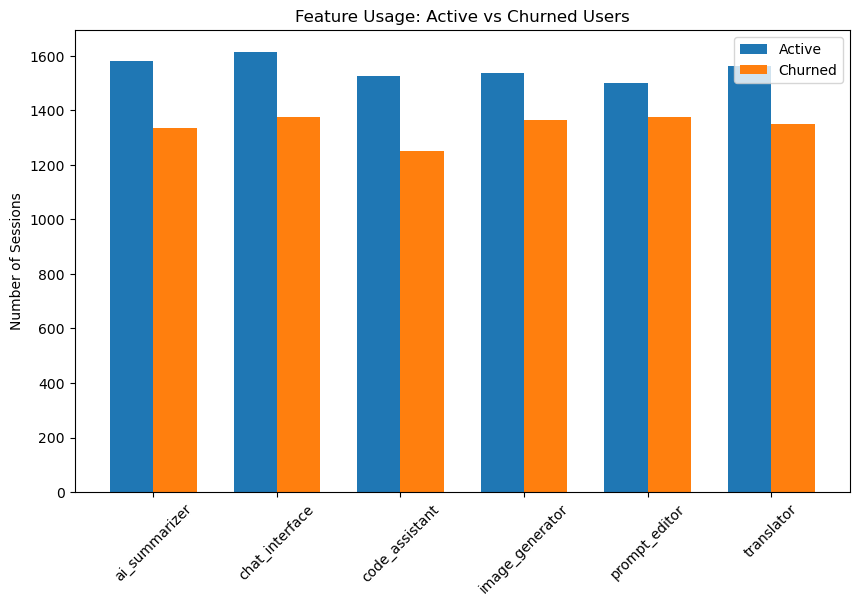

In [92]:
plt.figure(figsize=(10,6))
x = np.arange(len(df_active["feature_name"])) 
width = 0.35
plt.bar(x-width/2, df_active["count_status"], width, label="Active")
plt.bar(x+width/2, df_churned["count_status"], width, label="Churned")
plt.xticks(x,df_active["feature_name"])
plt.title("Feature Usage: Active vs Churned Users")
plt.ylabel("Number of Sessions")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 5.2 Churn Reasons Distribution

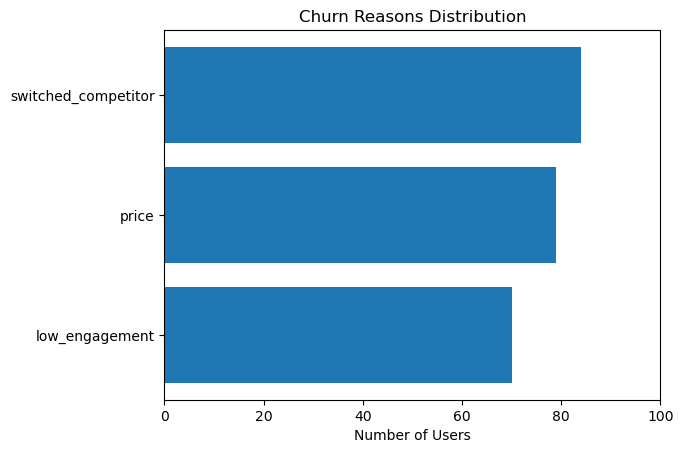

In [93]:
plt.figure()
plt.barh(df_churn_reason["reason"],df_churn_reason["churn_reason_count"])
plt.xlim(0, 100)
plt.title("Churn Reasons Distribution")
plt.xlabel("Number of Users")
plt.show()

### 5.3 Churn Rate by Country

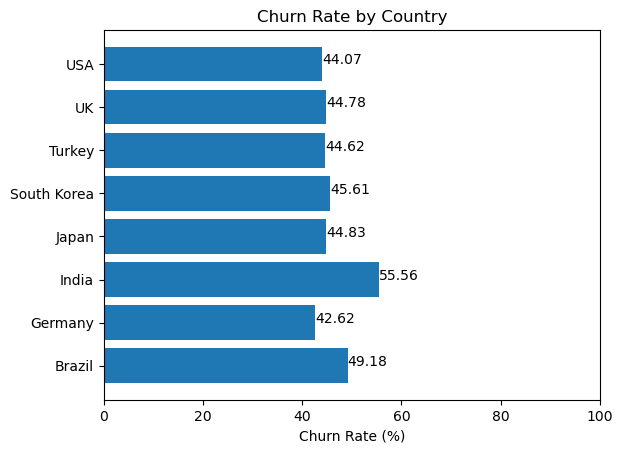

In [94]:
plt.figure()
plt.barh(df_country_churn["country"],df_country_churn["per_user"])
plt.xlim(0, 100)
for i, row in df_country_churn.iterrows():
    plt.text(row["per_user"], row["country"], round(row["per_user"], 2))
plt.title("Churn Rate by Country")
plt.xlabel("Churn Rate (%)")
plt.show()

### 5.4 Monthly Churn Trend

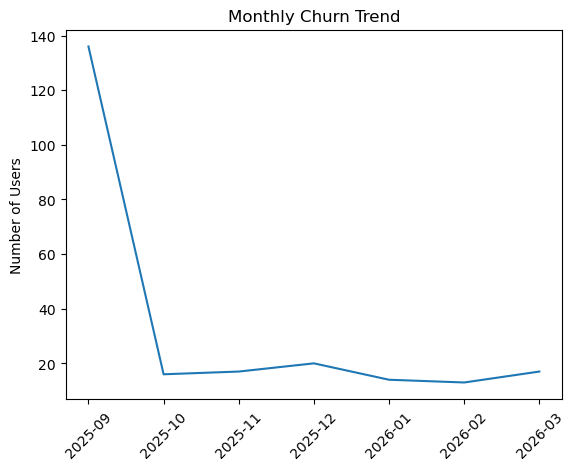

In [95]:
plt.figure()
plt.plot(df_churn_trend["churn_date"].astype(str),df_churn_trend["user_count"])
plt.title("Monthly Churn Trend")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

### 5.5 Churn by Plan Type

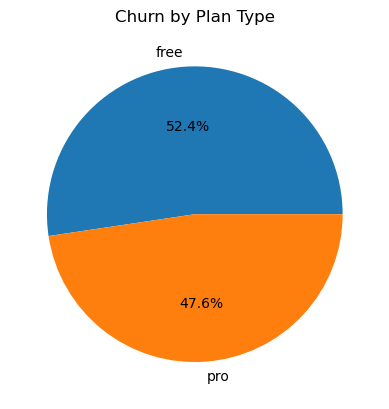

In [96]:
plt.figure()
plt.pie(df_churn_plan["per_user_churn"],labels=df_churn_plan["plan_type"],autopct="%1.1f%%")
plt.title("Churn by Plan Type")
plt.show()

## 6. Insights & Recommendations

### Key Insights

- Nearly half of all users have churned (46.6%), which is a high churn rate for a SaaS product.

  *Note: This dataset is synthetic. In a real product, a churn rate this high would first trigger a data validation check before proceeding to analysis.*

- Pro users churn at a slightly higher rate than free users (47% vs 46%). Paying users leaving more suggests a product quality gap, not a pricing issue.
- **prompt_editor** has the highest session duration but is most associated with churned users. Users invest time but still leave — possible UX or output quality problem.
- **code_assistant** is the least used feature overall. May reflect low demand or poor discoverability.
- The top churn reason is switching to a competitor (84 users), not price or low engagement. This points to a product differentiation problem.
- Active and churned users show very similar session durations (3185 vs 3053 avg). Users were engaged but still left — further evidence of a product quality issue.
- India is the only country where churned users outnumber active users (55.6% churn rate).
- September 2025 had a significant churn spike (136 users) that warrants immediate investigation.

  *Note: This spike is partly an artifact of synthetic data design. In real product data, churn spikes tend to be less sharp but still warrant immediate root cause analysis.*

### Recommendations

1. **Investigate prompt_editor UX and output quality :** prompt_editor has the highest session duration but is strongly associated with churned users. Users invest time but still leave. UX research and output quality review are recommended to identify friction points.

2. **Address competitive positioning for Pro users :** Pro users' top churn reason is switching to a competitor, not price. This suggests a feature or quality gap versus competitors. A comparative product analysis would help identify where the product falls short.

3. **Investigate code_assistant adoption :** code_assistant is the least used feature overall. The team should evaluate whether to improve discoverability, enhance the feature, or reconsider its positioning.

4. **Investigate the September 2025 churn spike :** A significant spike occurred in September 2025. Root cause analysis should cover both external events (competitor launches, market shifts) and internal changes (product updates, pricing changes).